# Step 1 - Hyperbolic Embedding (Spatial Backbone)

Step1/2 依赖空间坐标，因此这里使用 `data/ST/ST_CRC_MSS` 作为空间骨架进行双曲嵌入。

后续靶点发现与干预优先级将在 `03~05` 中由 `scCRC_ICB` 数据驱动完成。

In [1]:
from pathlib import Path
import subprocess

ROOT = Path.cwd().resolve().parent.parent if Path.cwd().name == "example_sccrc_icb_step_by_step" else Path.cwd().resolve()
OUT = ROOT / "results" / "examples" / "sccrc_icb" / "step1"
OUT.mkdir(parents=True, exist_ok=True)

cmd = [
    "python", "scripts/run_step1.py",
    "--data-dir", "data/ST/ST_CRC_MSS",
    "--modality", "visium",
    "--pretrain-epochs", "2",
    "--epochs", "5",
    "--latent-dim", "16",
    "--n-top-genes", "1200",
    "--device", "cpu",
    "--output-dir", str(OUT),
]
print(" ".join(cmd))
subprocess.run(cmd, cwd=ROOT, check=True)
print(f"Step1 done -> {OUT}")

python scripts/run_step1.py --data-dir data/ST/ST_CRC_MSS --modality visium --pretrain-epochs 2 --epochs 5 --latent-dim 16 --n-top-genes 1200 --device cpu --output-dir E:\HyperSCA\results\examples\sccrc_icb\step1


Step1 done -> E:\HyperSCA\results\examples\sccrc_icb\step1


Step1 figure generated locally


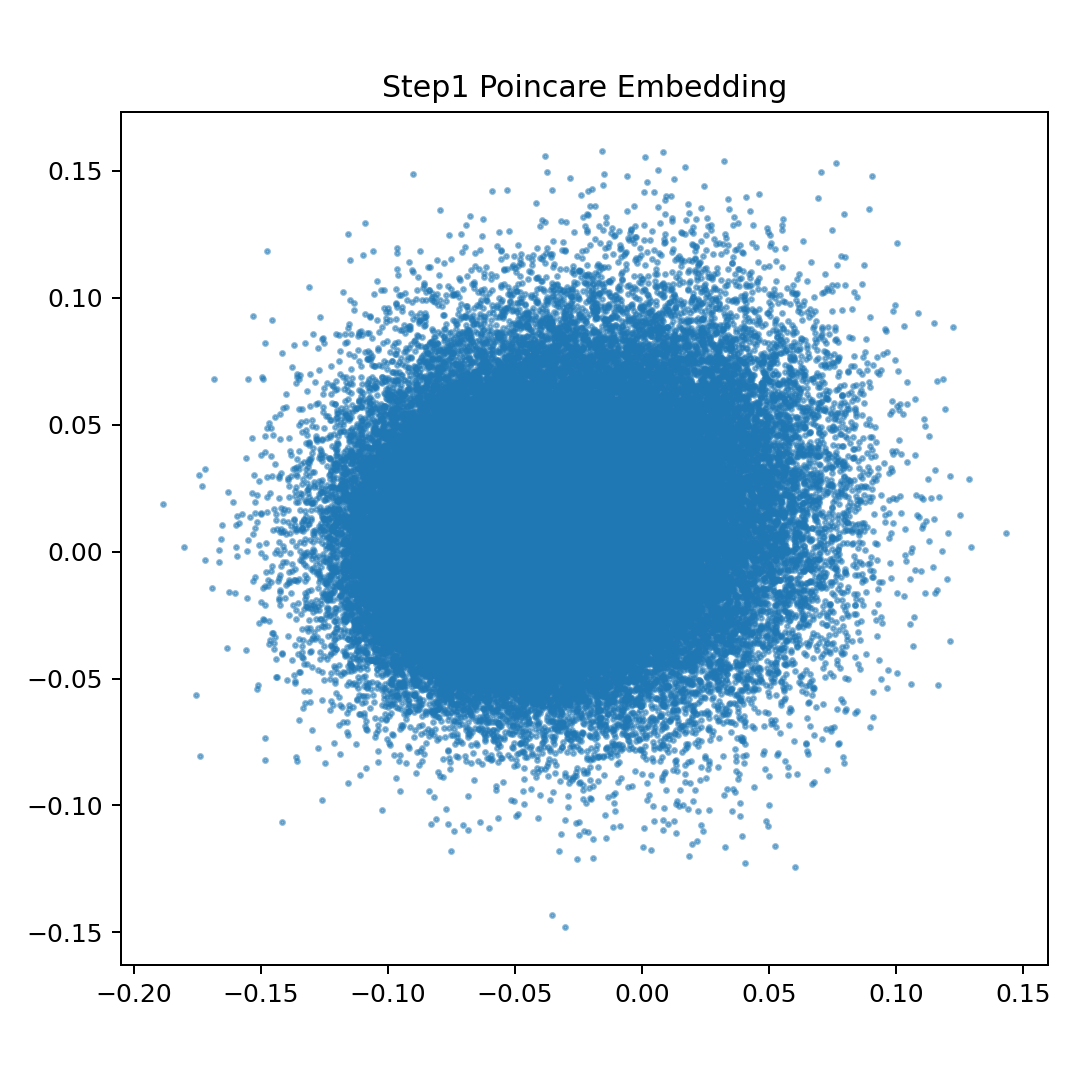

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

benchmark = json.loads((OUT / "embedding_benchmark.json").read_text(encoding="utf-8"))
print("Embedding benchmark:")
print(json.dumps(benchmark, ensure_ascii=False, indent=2))

poincare = np.load(OUT / "embeddings_poincare.npy")
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(poincare[:, 0], poincare[:, 1], s=3, alpha=0.6)
ax.set_title("Step1 Poincare Embedding (ST_CRC_MSS backbone)")
ax.set_xlabel("dim-1")
ax.set_ylabel("dim-2")
ax.set_aspect("equal")
plt.show()